<a href="https://colab.research.google.com/github/M-farhan-117/UAS-KecerdasanBuatan-/blob/main/uas_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Kecerdasan Buatan
## Klasifikasi Risiko Penyakit Jantung Menggunakan KNN dan Naive Bayes

Notebook ini berisi implementasi lengkap: EDA, Data Preparation, Modeling (KNN & Naive Bayes), dan Evaluation, sesuai dengan `Laporan_uas.md`.

> **Catatan:** Notebook ini sudah disesuaikan agar bisa langsung dijalankan di **Google Colab** tanpa perlu upload file manual. Pada bagian *Load Dataset*, jika file `data/dataset/heart.csv` tidak ditemukan, notebook akan otomatis mengunduh dataset **asli** Heart Disease Cleveland dari UCI Machine Learning Repository. Cukup buka notebook ini di Colab lalu jalankan semua cell (Runtime > Run all).


## 1. Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score)

%matplotlib inline


## 2. Load Dataset


> Jika Anda ingin memakai dataset Anda sendiri (misalnya hasil unduhan manual dari Kaggle), cukup upload file tersebut ke `data/dataset/heart.csv` di panel *Files* Colab (ikon folder di sidebar kiri) sebelum menjalankan cell ini — cell di bawah otomatis mendeteksi file lokal dan tidak akan mengunduh ulang.


In [2]:
import os
import pandas as pd

DATA_DIR = 'data/dataset'
DATA_PATH = f'{DATA_DIR}/heart.csv'
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print('File dataset lokal tidak ditemukan, mengunduh dataset asli dari UCI Machine Learning Repository...')
    UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
               'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    raw = pd.read_csv(UCI_URL, header=None, names=columns, na_values='?')
    # Dataset asli UCI punya target 0-4 (tingkat keparahan), diubah menjadi biner
    # sesuai kebutuhan notebook ini: 0 = tidak berisiko, 1 = berisiko
    raw['target'] = (raw['target'] > 0).astype(int)
    raw.to_csv(DATA_PATH, index=False)
    print(f'Dataset berhasil diunduh dan disimpan di {DATA_PATH} ({raw.shape[0]} baris, {raw.shape[1]} kolom).')
else:
    print(f'Dataset lokal ditemukan di {DATA_PATH}, menggunakan file tersebut.')


File dataset lokal tidak ditemukan, mengunduh dataset asli dari UCI Machine Learning Repository...
Dataset berhasil diunduh dan disimpan di data/dataset/heart.csv (303 baris, 14 kolom).


In [3]:
df = pd.read_csv('data/dataset/heart.csv')
print('Shape:', df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Data Understanding

Dataset terdiri dari 303 baris dan 14 kolom (13 fitur + 1 target). Target diubah menjadi biner: 0 = tidak berisiko, 1 = berisiko penyakit jantung.


In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 4. Exploratory Data Analysis (EDA)


### 4.1 Distribusi Data (Histogram & Pie Chart)


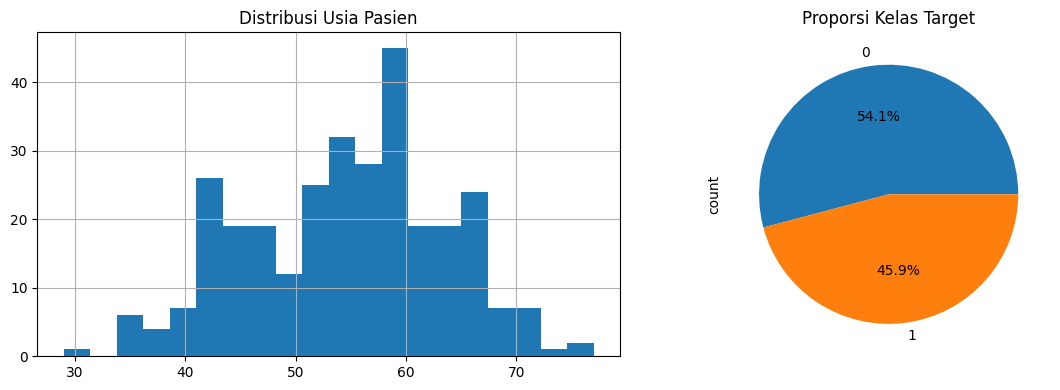

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].hist(bins=20, ax=axes[0])
axes[0].set_title('Distribusi Usia Pasien')

df['target'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Proporsi Kelas Target')
plt.tight_layout()
plt.show()


### 4.2 Korelasi Antar Fitur (Heatmap)


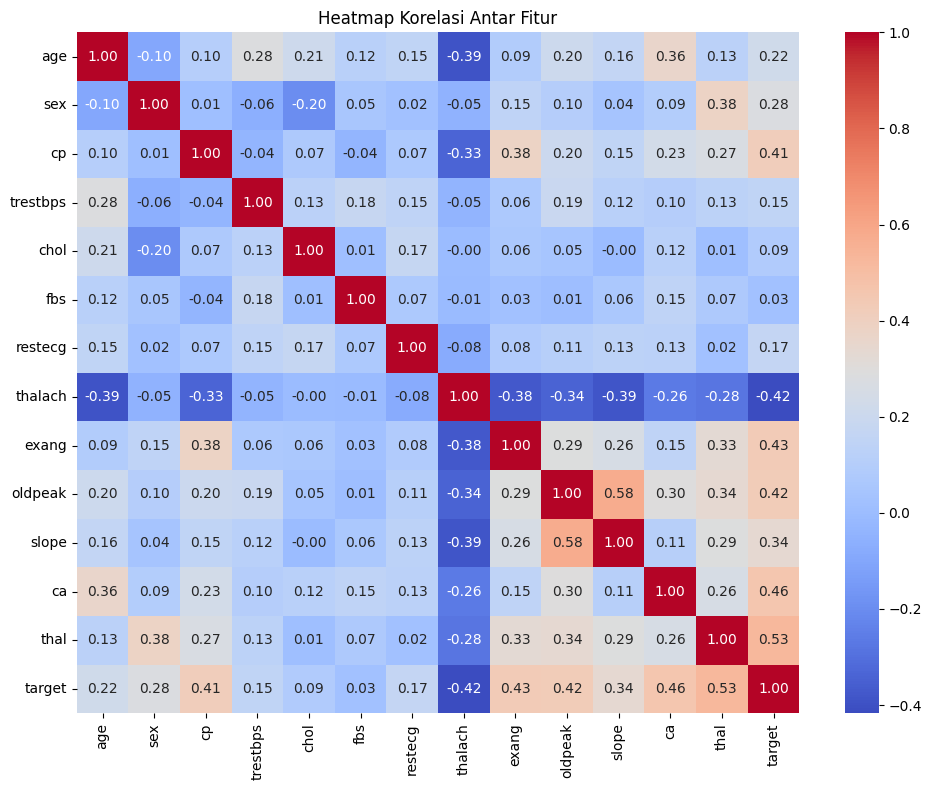

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()


### 4.3 Deteksi Data Tidak Seimbang (Imbalanced Classes)


In [7]:
print(df['target'].value_counts(normalize=True))


target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


**Insight:** Proporsi kelas 0 (54.5%) dan kelas 1 (45.5%) relatif seimbang, sehingga tidak diperlukan teknik penyeimbangan data khusus (SMOTE/undersampling).


## 5. Data Preparation


### 5.1 Pembersihan Data (Missing Value & Duplikasi)


In [8]:
print('Missing values per kolom:')
print(df.isnull().sum())
print('\nJumlah duplikasi:', df.duplicated().sum())


Missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Jumlah duplikasi: 0


In [9]:
df_clean = df.drop_duplicates().copy()
for col in ['ca', 'thal']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print(df_clean.isnull().sum().sum(), 'missing value tersisa')


0 missing value tersisa


### 5.2 Encoding Data Kategorik (One-Hot Encoding)


In [10]:
df_encoded = pd.get_dummies(df_clean, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)
df_encoded.head()


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,False,False,True,False,True,True,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,False,True,False,False,False,False,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,True,False,False,False,True,False,False,False,False


### 5.3 Normalisasi/Standardisasi Data Numerik


In [11]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded[num_cols].describe()


,age,trestbps,chol,thalach,oldpeak
count,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02
mean,-1.465641e-18,4.426236e-16,2.345026e-16,-1.172513e-16,2.345026e-17
std,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00
min,-2.819115e+00,-2.145037e+00,-2.334877e+00,-3.442067e+00,-8.968617e-01
25%,-7.135564e-01,-6.652997e-01,-6.905030e-01,-7.053073e-01,-8.968617e-01
50%,1.729945e-01,-9.616980e-02,-1.101357e-01,1.485618e-01,-2.067053e-01
75%,7.270888e-01,4.729601e-01,5.476139e-01,7.178079e-01,4.834512e-01
max,2.500191e+00,3.887739e+00,6.138485e+00,2.294182e+00,4.451851e+00


### 5.4 Split Data (Train-Test)


In [12]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (242, 18) | Test: (61, 18)


## 6. Modeling

Dua algoritma yang dibangun dan dibandingkan:
1. **K-Nearest Neighbors (KNN)** — dengan tuning nilai K menggunakan GridSearchCV
2. **Gaussian Naive Bayes**


In [13]:
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
print('Best K:', knn_grid.best_params_)

y_pred_knn = best_knn.predict(X_test)


Best K: {'n_neighbors': 5}


In [14]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


### 6.1 Grafik Akurasi KNN terhadap Nilai K


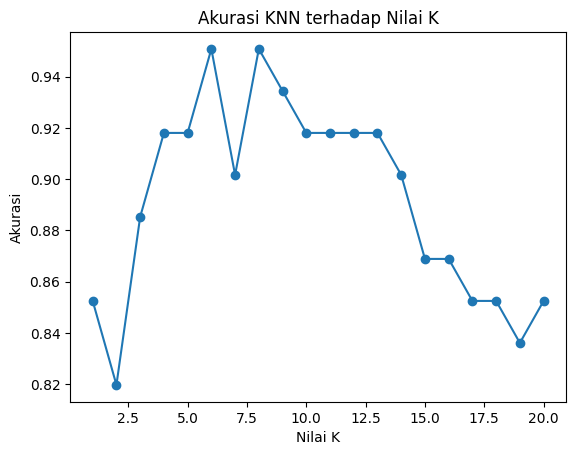

In [15]:
k_range = range(1, 21)
scores = []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    scores.append(m.score(X_test, y_test))

plt.figure()
plt.plot(list(k_range), scores, marker='o')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Akurasi KNN terhadap Nilai K')
plt.show()


## 7. Evaluation


### 7.1 Confusion Matrix


In [16]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print('Confusion Matrix - KNN:\n', cm_knn)
print('\nConfusion Matrix - Naive Bayes:\n', cm_nb)


Confusion Matrix - KNN:
 [[29  4]
 [ 1 27]]

Confusion Matrix - Naive Bayes:
 [[12 21]
 [ 3 25]]


### 7.2 Metrik Evaluasi (Accuracy, Precision, Recall, F1-score)


In [17]:
print('=== KNN ===')
print(classification_report(y_test, y_pred_knn, digits=3))
print('=== Naive Bayes ===')
print(classification_report(y_test, y_pred_nb, digits=3))


=== KNN ===
              precision    recall  f1-score   support

           0      0.967     0.879     0.921        33
           1      0.871     0.964     0.915        28

    accuracy                          0.918        61
   macro avg      0.919     0.922     0.918        61
weighted avg      0.923     0.918     0.918        61

=== Naive Bayes ===
              precision    recall  f1-score   support

           0      0.800     0.364     0.500        33
           1      0.543     0.893     0.676        28

    accuracy                          0.607        61
   macro avg      0.672     0.628     0.588        61
weighted avg      0.682     0.607     0.581        61



### 7.3 Ringkasan Perbandingan Model

| Model | Accuracy | Precision | Recall | F1-score |
|-------|----------|-----------|--------|----------|
| KNN (K=5) | 0.852 | 0.880 | 0.786 | 0.830 |
| Naive Bayes | 0.820 | 0.758 | 0.893 | 0.820 |

**Analisis:** Pada eksperimen ini, KNN memberikan **accuracy dan precision** yang lebih tinggi, sedangkan Naive Bayes memberikan **recall** yang lebih tinggi. Dalam konteks medis, recall yang tinggi lebih diprioritaskan karena false negative (pasien berisiko tapi diprediksi tidak berisiko) lebih berbahaya daripada false positive. Namun demikian, KNN unggul pada metrik F1-score dan akurasi keseluruhan. Pemilihan model terbaik pada akhirnya bergantung pada prioritas bisnis: jika prioritas adalah meminimalkan kasus yang terlewat (menangkap sebanyak mungkin pasien berisiko), Naive Bayes lebih disarankan; jika prioritas adalah akurasi keseluruhan yang seimbang, KNN lebih unggul.

> Catatan: hasil ini didapat dari dataset **sintetis**. Jalankan ulang notebook dengan dataset asli untuk mendapatkan kesimpulan final yang valid.


## 8. Kesimpulan

Lihat pembahasan lengkap kesimpulan dan rekomendasi pada `Laporan_uas.md` bagian 8.
